# Part 2: New dataset. 


## Value of this file: 
## 1) find out what vars we can open
## 2) We learn IPFS by looking at IPFS of surviving events in last cell

* We made sure here that we are reading the data correctly
* We remove events that lack have empty entries in 1 or more of the var's we're inspecting
* we visually look at the cuts one at a time to see how they cut away stuff that isn't signal (some NC pi0 is irreducible)
* We also wanted to better understand IPFS (identity particles final state) to device a physics based LDA labeling
* We also run PCA and LDA on the 1 data set and get only 12 survivors (I REMOVED THIS ONE AS WE DO THIS SAME THING ON MORE FILES IN PART 3)


In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

understanding what variables we can work with + how data is structured into ak arrays

In [2]:
# this is the file after i ran the hadd thing (see my shared presentation with the Professor, where I outline how to do this compression conversion in detail)
file = uproot.open("may07_2_cocktail_allhad_nc_1500.root")
tree = file["MiniBooNE;1"]

In [3]:
mc_data_INNO = tree["TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.INNO"].array()

print(mc_data_INNO)

[[1], [1], [1], [1], [1], [1], [1], [1], ..., [1], [1], [1], [1], [1], [1], [1]]


In [4]:
#lets see which MCEVNT branches work
for branch in tree.keys():
    if "TMonteCarloEVNTChunk" in branch and "data_" in branch: #take the relevant MCEVNT branches while ignroring all the stuff I know works from before
        try:
            test = tree[branch].array()
            print(f"OK {branch.split('.')[-1]}") #the branch names are long so take the last bit

          #  print(tree[branch].array()[:5])

        except:
            print(f"X  {branch.split('.')[-1]}")

print(f"PNEU4 {tree['TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.PNEU[4]'].array()[:2]}")

OK fUniqueID
OK fBits
OK VERSION
OK VAR_FLAGS
OK IEVNT
OK EVWT
OK INNO
OK PNEU[4]
OK NDCY
OK NFSP
OK VRTX[127][3]
X  TIME
X  IPFS
OK PFSP[127][4]
X  NHTTCER
X  NHTTSCI
OK NPROCTAG
X  IPROCTAG
OK NHTT
X  NOTPMT
X  TITPMT
OK RNDM1
OK RNDM2
PNEU4 [[[-0.000479, 0.0115, 1, 3.22]], [[0.000454, 0.0027, 1, 1.25]]]


In [5]:
# Check the most likely candidates
print("Checking TSplitEventChunk THits and VHits:")
thits = tree["TSplitEventChunk/TSplitEventChunk.data_.THits"].array()
vhits = tree["TSplitEventChunk/TSplitEventChunk.data_.VHits"].array()

print(f"THits length: {len(thits)}, first 5: {thits[:5]}")
print(f"VHits length: {len(vhits)}, first 5: {vhits[:5]}")

# Check if your empty reconstruction correlates with these cuts
print(f"Events with THits <= 200: {np.sum(thits <= 200)}")
print(f"Events with VHits >= 6: {np.sum(vhits >= 6)}")

Checking TSplitEventChunk THits and VHits:
THits length: 3104, first 5: [[155], [1039, 130], [317], [47], [559, 915]]
VHits length: 3104, first 5: [[0], [0, 0], [17], [0], [0, 46]]
Events with THits <= 200: 3015
Events with VHits >= 6: 1849


In [6]:
#likewise lets see which kinematic branches work 
for branch in tree.keys():
    if "TOneTrackChunk" in branch: #take the relevant MCEVNT branches while ignroring all the stuff I know works from before
        try:
            test = tree[branch].array()
            print(f"OK {branch.split('.')[-1]}") #the branch names are long so take the last bit

          #  print(tree[branch].array()[:5])

        except:
            print(f"BAD {branch.split('.')[-1]}")

OK TOneTrackChunk
OK chunk_id_
OK fUniqueID
OK fBits
OK iterations
OK trackType
OK X
OK Y
OK Z
OK UX
OK UY
OK UZ
OK T
OK E
OK distToMeanCer
OK fluxScale
OK relativeSci
OK F
OK name_


In [7]:
for branch in tree.keys():
    if "TTwoTrackChunk" in branch: #take the relevant MCEVNT branches while ignroring all the stuff I know works from before
        try:
            test = tree[branch].array()
            print(f"OK {branch.split('.')[-1]}") #the branch names are long so take the last bit

          #  print(tree[branch].array()[:5])

        except:
            print(f"BAD {branch.split('.')[-1]}")

OK TTwoTrackChunk
OK chunk_id_
OK fUniqueID
OK fBits
OK trackType1
OK trackType2
OK X
OK Y
OK Z
OK T
OK M
OK CosOp
OK UX1
OK UY1
OK UZ1
OK E1
OK distToMeanCer1
OK S1
OK UX2
OK UY2
OK UZ2
OK E2
OK distToMeanCer2
OK S2
OK fluxScale
OK relativeSci
OK Fqqq
OK Fttt
OK F
OK fixedMass
OK name_


In [8]:
#GORUND TRUTH (Nuance channel and also INNO)

#this is the nuance chanlel that we want to do LDA on (later we must find a way to also integrate neutrino flavor into the LDA's ground truth)
nuance_channels = tree["TReweightToCVChunk/TReweightToCVChunk.data_.nuanceChannel"].array()
print(f"lenght: {len(nuance_channels)}")
print(f"Unique channels: {np.unique(nuance_channels)}")
print(f"First 10 values: {nuance_channels[:10]}")

INNO_array = tree["TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.INNO"].array()
print(f"lenght: {len(INNO_array)}")
print(f"Unique channels: {np.unique(INNO_array)}")
print(f"First 10 values: {INNO_array[:10]}")
print(f"the # of types 1,2,3,4 are {np.sum(INNO_array ==1)},{np.sum(INNO_array ==2)},{np.sum(INNO_array ==3)},{np.sum(INNO_array ==4)}")

lenght: 3104
Unique channels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 13, ..., 80, 82, 83, 91, 92, 93, 94, 95, 96, 97]
First 10 values: [[9], [18], [1], [2], [6], [9], [2], [6], [1], [3]]
lenght: 3104
Unique channels: [1, 2, 3, 4]
First 10 values: [[1], [1], [1], [1], [1], [1], [1], [1], [1], [1]]
the # of types 1,2,3,4 are 3047,32,22,3


How many evnts have entries? (turns out M and twotrack E has entries for ~10% of events only)

In [9]:
#checking contents of some vars i want to do LDA on
onetrack_E = tree["TOneTrackChunk/TOneTrackChunk.data_.E"].array()
print(onetrack_E)
print(f"empty entries in one track E {np.sum(np.array([len(entry) == 0 for entry in onetrack_E]))}")

onetrack_F = tree["TOneTrackChunk/TOneTrackChunk.data_.F"].array()
print(onetrack_F)
print(f"empty entries in one track F {np.sum(np.array([len(entry) == 0 for entry in onetrack_F]))}")

onetrack_X = tree["TOneTrackChunk/TOneTrackChunk.data_.X"].array()
print(onetrack_X)
print(f"empty entries in one track X {np.sum(np.array([len(entry) == 0 for entry in onetrack_X]))}")

twotrack_E1 = tree["TTwoTrackChunk/TTwoTrackChunk.data_.E1"].array()
print(twotrack_E1)
print(f"empty entries in two track E1 {np.sum(np.array([len(entry) == 0 for entry in twotrack_E1]))}")

twotrack_E2 = tree["TTwoTrackChunk/TTwoTrackChunk.data_.E2"].array()
print(twotrack_E2)
print(f"empty entries in two track E2 {np.sum(np.array([len(entry) == 0 for entry in twotrack_E2]))}")

twotrack_M = tree["TTwoTrackChunk/TTwoTrackChunk.data_.M"].array()
print(twotrack_M)
print(f"empty entries in two Twotrack mass {np.sum(np.array([len(entry) == 0 for entry in twotrack_M]))}")



[[56, 125], [1.07e+03, 54.5, 1.11e+03], ..., [...], [104, 51.6, 1.75e+03, 173]]
empty entries in one track E 361
[[1.35, 1.34], [6.66, 0.971, 6.76], ..., [4.34, ...], [1.77, 0.796, 6.14, 1.72]]
empty entries in one track F 361
[[-66.4, 59.7], [-20.6, -56.5, -26.1], ..., [35.9, ...], [284, 291, -199, 347]]
empty entries in one track X 361
[[], [], [], [], [], [], [], [], ..., [128, ...], [], [], [], [], [], [], []]
empty entries in two track E1 2927
[[], [], [], [], [], [], [], [], ..., [120, ...], [], [], [], [], [], [], []]
empty entries in two track E2 2927
[[], [], [], [], [], [], [], [], ..., [56.2, ...], [], [], [], [], [], [], []]
empty entries in two Twotrack mass 2927


In [10]:
#there are the hit vars
hits = tree["TSplitEventChunk/TSplitEventChunk.data_.THits"].array()
nveto = tree["TSplitEventChunk/TSplitEventChunk.data_.VHits"].array()

# these are jagged arrays so extract all the 1st subevents
hits_first = ak.firsts(hits)
nveto_first = ak.firsts(nveto)

print(f"here's the first 2 entries of hits {hits[:2]}")
print(f"here's the first 2 entries of hits_first {hits_first[:2]}")

# Check the cuts
print(f"Total events: {len(hits_first)}")
print(f"events w hits > 200: {ak.sum(hits_first > 200)}") # reguatr sum() cant handlle [] entries....
print(f"events w Nveto < 6: {ak.sum(nveto_first < 6)}")

here's the first 2 entries of hits [[155], [1039, 130]]
here's the first 2 entries of hits_first [155, 1039]
Total events: 3104
events w hits > 200: 1853
events w Nveto < 6: 1678


In [11]:
# i wanna see if all entries with el.E also have mu.E
onetrack_E = tree["TOneTrackChunk/TOneTrackChunk.data_.E"].array()

# so lets just replace each evnt by the number of subevents 
num_entries_per_event = ak.num(onetrack_E)

print(f"Total events: {len(onetrack_E)}")
print(f"Events with 0 entries: {ak.sum(num_entries_per_event == 0)}")
print(f"Events with 1 entry: {ak.sum(num_entries_per_event == 1)}")
print(f"Events with 2 entries: {ak.sum(num_entries_per_event == 2)}")
print(f"Events with 3+ entries: {ak.sum(num_entries_per_event >= 3)}")
print(f"Max entries in any event: {ak.max(num_entries_per_event)}")

Total events: 3104
Events with 0 entries: 361
Events with 1 entry: 43
Events with 2 entries: 1165
Events with 3+ entries: 1535
Max entries in any event: 8


### Slightly less naive LDA approach (before we did every INNOxNuance channel combo, i.e. 4x99=396 combos. this caused bad LDA and i deleted that code to unclog this ipynb file): 
1) applying some masks and 
2) grouping some physically similar categories together

In [12]:
#summary: Ive already created a function "turn IPFS dump tolist" which takes IPFS dump (format specified above) and turns it into a list of 8-vectors for each evnt
#the 8 subentries for each event (aka entry) is # of particles 1thru3 and 5thru9. 1 is gamma. 2,3,5,6 are leptons, and 7thru9 are pions
#anyway input all the onetrack and splitEvnt data we care about
#process it thru 2 masks (200nhits, 6veto hits, evnts that have 1st and 2nd entries in oneTrack
#then process the oneTrack data (eg. el.F - mu.F) and get spherical and cylindrical coordinates (I created function for this)
#then I turn the 8-vectors into integer labels (turns out theres order of 100 independent 8 vectors)
#then scale the matrix w all the data, run LDA, and output the LD1 and LD2
#!!!! NOTICE that, slightly akwardly, i push in all split_vars that open automatically, whereas for onetrack vars i decide later on which to include (i took basically all these anyway)
#this is because im constructing new OneTrack-derived vars anyway... and I dont want an extra input unnecessarily 

from utils import *

#just get vars
split_first, _, split_success = extract_branches(tree, map_split_vars)

ot_first, ot_second, _ = extract_branches(tree, map_onetrack_vars)


# roll out the mask that only keeps the evnts w 0th and 1st entries. (stupidly i called them first and second because im human...)
#basically this first filter isnt one of the real cuts from the paper. its just cutting out stuff that doesnt have oneTrack and TwoTrack entries (after the cuts in mask2, theres basically only these evnts that survive anyway as i showed in the box below)
#also notice i stupidly did this annoying padnone stuff for the oneTrack lists before i learnt about the ak.num function.
mask1 = ~ak.is_none(ot_first['E']) & ~ak.is_none(ot_second['E']) & (ak.num(twotrack_M)>0) #will return [True, False, False, ...]

sub_event_filtered = sub_event_list[mask1] #here im just taking the subevents only of the relevant events by passing subevnt list thru mask1

indices1 = np.where(mask1)[0] #this just returns an array of the places where mask gives true e.g. [True, False,True] gives [0,2]. good to keep track for later 
split_filtered = apply_mask({k: split_first[k] for k in split_success}, mask1) # filtered vars
ot_first_filtered = apply_mask(ot_first, mask1)
ot_second_filtered = apply_mask(ot_second, mask1)
twotrack_M_filtered = twotrack_M[mask1] #we also gotta pass twotrack_M thru mask1
twotrack_F_pi0_filtered = twotrack_F_pi0[mask1]
 

#more vars that have gone thru first filter
coords_el = calc_coords(ot_first_filtered)


#"endpoint_R_mu" cut requires us to have a bunch of vars from Onetrack_mu
mu_X =ot_second_filtered["X"]
mu_UX =ot_second_filtered["UX"] 
mu_Y =ot_second_filtered["Y"] 
mu_UY =ot_second_filtered["UY"]
mu_Z =ot_second_filtered["Z"] 
mu_UZ =ot_second_filtered["UZ"] 
delta_func =ot_second_filtered['distToMeanCer']
#heres how the formula in 10.1 of Ryans thesis calculates this:
endpoint_R_mu = np.sqrt((mu_X + 2*delta_func*mu_UX)**2 + (mu_Y + 2*delta_func*mu_UY)**2 + (mu_Z + 2*delta_func*mu_UZ)**2)



#it turns out that the ((ot_first_filtered['F'] - ot_second_filtered['F']) < 0) cut is not correct.
#Rather it turns out theres this polynomial cut
E_e = ot_first_filtered['E']  # Electron energy
log_Le_over_Lmu = ot_second_filtered['F'] - ot_first_filtered['F']  # Fμ - Fe... b/c the F's are -log likelihood
threshold_Le_Lmu =  0.01358 + 0.03467*E_e/1000 - 0.008259*E_e**2/10**6
threshold_M = 0.03203 *1000 + 0.007417*E_e + 0.02738*E_e**2/1000
#heres the el.F-pi.F cut:
log_Le_over_Lpi = twotrack_F_pi0_filtered[:,1] - ot_first_filtered['F']
threshold_Le_Lpi = 0.002471 + 0.004115*E_e /1000 - 0.02738*E_e**2/10**6

#roll out mask2. I'll keep the same variable name for the dictionaries
#VERY IMPORTANT: el.F and mu.F are NEGATIVE(!!!) LOG LIKELIHOOD. SO log(el/mu)>0 means that el.F-mu.F<0
mask2 = ( (split_filtered['nhits'] > 200) & 
         (split_filtered['nveto'] < 6) & 
        (coords_el["R_spher"] < 500) & 
        (log_Le_over_Lmu > threshold_Le_Lmu) & 
        (twotrack_M_filtered[:,0] < threshold_M) & #notice that twotrack_M_filtered has 2 entries. each will look like [some_value,135]. So clearly 0th entry is the unconstrained mass (bc constrained mass assuming pi0 will always be 135 MeV)
        (ak.num(sub_event_filtered) == 1) ) #&
       # (endpoint_R_mu < 488) &
      #  (log_Le_over_Lpi > threshold_Le_Lpi)
      #  ) #parentheses are just for operator precedence. ak.num(list) just counts number of entries within a list eg ak.num([[1], [1,1], [1,1,1]]) is [1,2,3] 

#DICTIONARIES WE GET ALL THE FILTERED VARS FROM AFTER CUTS

final_indices = indices1[mask2] #a list
split_filtered = apply_mask(split_filtered, mask2) #dict
ot_first_filtered = apply_mask(ot_first_filtered, mask2) #dict
ot_second_filtered = apply_mask(ot_second_filtered, mask2)#dict
coords_el = apply_mask(coords_el, mask2) #dict

#!!!!!!!!!!!!!!!!!
#OK NOW WE HAVE ALL THE DICTIIONARIES WITH ALL THE BRANCHES WE NEED
#NOW IM DECIDING WHAT TO MAKE USE OF

E_el = ot_first_filtered['E']
E_mu = ot_second_filtered['E']
E_sum = E_el + E_mu

onetrack_vars_we_run_LDA_on = [
    # energy stuff
    (E_el, 'el.E'),
    (E_mu, 'mu.E'),
    (np.log(E_el), 'log(el.E)'),
    (np.log(E_mu), 'log(mu.E)'),
    (E_el / E_sum, 'el_E_fraction'),
    (E_mu / E_sum, 'mu_E_fraction'),
    ((E_el - E_mu) / E_sum, 'E_diff'),
    # F and T stuf
    (ot_first_filtered['F'], 'el.F'),
    (ot_second_filtered['F'], 'mu.F'),
    (ot_first_filtered['F'] - ot_second_filtered['F'], 'F_diff'),
    (ot_first_filtered['T'], 'el.T'),
    (ot_second_filtered['T'], 'mu.T'),
    #coordinate vars
    (coords_el['r_cyl'], 'el_r_cyl'),
    (coords_el['phi_cyl'], 'el_phi_cyl'),
    (coords_el['R_spher'], 'el_R_spher'),
    (coords_el['theta_spher'], 'el_theta_spher'),
    (coords_el['ur_cyl'], 'el_ur_cyl'),
    (coords_el['uphi_cyl'], 'el_uphi_cyl'),
    (coords_el['UR_spher'], 'el_UR_spher'),
    (coords_el['u_theta_spher'], 'el_u_theta_spher'),
    
    (ot_first_filtered['X'], 'el_X'),
    (ot_first_filtered['Y'], 'el_Y'),
    (ot_first_filtered['Z'], 'el_Z'),
    (ot_first_filtered['UX'], 'el_UX'),
    (ot_first_filtered['UY'], 'el_UY'),
    (ot_first_filtered['UZ'], 'el_UZ'),
    (ot_first_filtered['distToMeanCer'], 'el_distToMeanCer'),
    (ot_first_filtered['fluxScale'], 'el_fluxScale'),
    (ot_first_filtered['relativeSci'], 'el_relativeSci')]

#its kinda awkaward that split_filtered is dictionary and onetrack_vars_we_run_LDA_on is a list of tuples, but whatever....
data_matrix, var_names = build_data_matrix(split_filtered,  onetrack_vars_we_run_LDA_on)

scaler = StandardScaler()
data_matrix = scaler.fit_transform(data_matrix)

#create LDA labels based on these IPFS 8 vectors
#basically take all the events that survived masks,
#look at all the 8vectors
filtered_particles_counts_all_events = [counts_relevant_particles_all_events[i] for i in final_indices]
unique_patterns = {}
pattern_labels = []
events_with_electrons = {}
events_with_positrons = {}


#basically pattern_labels is the list of lables we push into LDA. 
#the unique_patterns dictionary just helps us decide whether to assign a new, higher number to the 8-vector or if we already gave that 8-vec a number
#I'm asked to lump 3+ gammas into the same category as 3 gammas, and (more than 2)==2 for all 3 pion categories
#thusI'll also implelemtnt "if" statements  
for vec in filtered_particles_counts_all_events:
    
    #just remember if it becomes relevant later that im over-riding the original filtered_particles_counts_all_evnts. so im basiclaly removing info by doing the groupings below
    if vec[0] > 3: #photon
        vec[0] = 3
    for i in [5,6,7]: #the 3 pions
        if vec[i] > 1:
            vec[i] = 1
    vec[1] += vec[2] #lump the e+ and e- together (ill add e- counts to e+ subentry then set the e- entry to zero for all evnts)
    vec[2] = 0

    pattern = tuple(vec)

    if pattern not in unique_patterns:
        unique_patterns[pattern] = len(unique_patterns) #unique_patterns is a dictionary. so itll map {pattern0:0,pattern1:1, etc} as it finds stuff
    pattern_labels.append(unique_patterns[pattern]) #pattern_labels is a list that might be 0,5,3,0,2 etc that says which # of unique pattern each evnt has

ipfs_labels = np.array(pattern_labels) #turn this list [0,3,2,5,43,2, ...] into array

print(f"unique_patterns {filtered_particles_counts_all_events}")

#RUN 
lda = LinearDiscriminantAnalysis()
data_lda = lda.fit_transform(data_matrix, ipfs_labels)


plt.figure(figsize=(7, 6))
scatter = plt.scatter(data_lda[:, 0], data_lda[:, 1], c=ipfs_labels, alpha=0.5, cmap='viridis')
plt.xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='IPFS pattern ID')
plt.tight_layout()
plt.title("LDA for the first 7 cuts; ")
plt.show()


for index in [0,1]:
    coeffs = np.abs(lda.scalings_[:, index]) #take the absolute # of coeffs for the 0th column (LD1)
    top_branches = np.argsort(coeffs)[-7:][::-1] #np.argsort takes the list of coeffs and reorders it s.t. u get the u get the numbers of the most imprtnt vars on top. eg var27 is the most imprtnt then var24 etc
    print(f"most imprtnt vars in LD{index+1}")
    for branch in top_branches:
        print(f"{var_names[branch]}")

OK nhits
OK nveto
OK tqpos
OK rmsttim
OK E
OK F
OK T
OK chunk_id
OK fUniqueID
OK fBits
OK iterations
OK trackType
OK X
OK Y
OK Z
OK UX
OK UY
OK UZ
OK distToMeanCer
OK fluxScale
OK relativeSci


NameError: name 'sub_event_list' is not defined

#### some stats

In [13]:
#i just want some info on what theis splitevnt subevent branch outputs cuz i think its one of the selection cuts
sub_event_list = tree["TSplitEventChunk/TSplitEventChunk.data_.Subevent"].array()

print(sub_event_list)
print(len(sub_event_list))

[[1], [1, 2], [1], [1], [...], ..., [1, 2, 3], [1, 2, 3], [1, 2, 3], [1, 2, 3]]
3104


#### #do the evnts with electrons in IPFS all correspond to v_e_bar? (yes)
#### what nuance channels to these v_e_bar/e- evnts correspond to? (many)


## Investigate IPFS data 

In [14]:
# i will investigate how for evnts that have 0,1,2,3 photons, how many particles exists of the following types
# #pi0, #eta (17), #e+, # e-

def modified_turn_IPFS_dump_to_list(IPFS_dump_file):
    
    counts_all_events = []
    particle_map = {"1":0, "2":1, "3":2, "7":3, "17":4} #gamma, e+,e-,pi0,eta
    
    with open(IPFS_dump_file, 'r') as IPFS_dump:
        for line in IPFS_dump:

            counts_one_event = [0,0,0,0,0]
            particle_list_for_this_event = ((line.strip()).split())[2:]
            for ID in particle_list_for_this_event:
                if ID in particle_map:
                    counts_one_event[particle_map[ID]] += 1
            
            counts_all_events.append(counts_one_event)
    
    return counts_all_events #this list of 5-vectors is 3104 entries long



counts_particles_0_gamma = []
counts_particles_1_gamma = []
counts_particles_2_gamma = []
counts_particles_3_gamma = []
counts_particles_4_gamma = []

for entry in modified_turn_IPFS_dump_to_list(r'C:\Users\Mathias\Desktop\NEUTRINO CODING\event # followed by NFSP followed by IPFS.txt'):
    if entry[0] == 0:
        counts_particles_0_gamma.append(entry)
    if entry[0] == 1:
        counts_particles_1_gamma.append(entry)
    if entry[0] == 2:
        counts_particles_2_gamma.append(entry)
    if entry[0] == 3:
        counts_particles_3_gamma.append(entry)
    if entry[0] == 4:
        counts_particles_4_gamma.append(entry)


print("gamma==0 ")
print("gamma, e+,e-,pi0,eta")
np_array = np.array(counts_particles_0_gamma)
print(np_array)

print("\ngamma==1 ")
print("gamma, e+,e-,pi0,eta")
np_array = np.array(counts_particles_1_gamma)
print(np_array)

print("\ngamma==2")
print("gamma, e+,e-,pi0,eta")
np_array = np.array(counts_particles_2_gamma)
print(np_array)

print("\ngamma==3")
print("gamma, e+,e-,pi0,eta")
np_array = np.array(counts_particles_3_gamma)
print(np_array)

print("\ngamma==4")
print("gamma, e+,e-,pi0,eta")
np_array = np.array(counts_particles_4_gamma)
print(np_array)

gamma==0 
gamma, e+,e-,pi0,eta
[[0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 ...
 [0 1 1 0 0]
 [0 1 1 0 0]
 [0 0 1 0 0]]

gamma==1 
gamma, e+,e-,pi0,eta
[[1 0 0 0 0]
 [1 0 1 0 0]
 [1 1 1 0 0]
 ...
 [1 0 1 0 0]
 [1 1 1 0 0]
 [1 0 1 0 0]]

gamma==2
gamma, e+,e-,pi0,eta
[[2 1 1 1 0]
 [2 0 0 0 0]
 [2 1 1 0 0]
 ...
 [2 0 1 0 0]
 [2 0 0 1 0]
 [2 0 0 0 0]]

gamma==3
gamma, e+,e-,pi0,eta
[[3 0 0 1 0]
 [3 0 0 0 0]
 [3 0 1 0 0]
 ...
 [3 0 0 0 0]
 [3 0 0 0 0]
 [3 0 1 0 0]]

gamma==4
gamma, e+,e-,pi0,eta
[[4 0 0 0 0]
 [4 0 1 0 0]
 [4 0 1 0 0]
 [4 0 0 1 0]
 [4 0 1 0 0]
 [4 0 0 0 0]
 [4 0 0 1 0]
 [4 0 1 0 0]
 [4 0 0 0 0]
 [4 0 1 2 0]
 [4 0 1 0 0]
 [4 0 1 0 0]
 [4 0 0 0 0]
 [4 1 0 1 0]
 [4 0 1 0 0]
 [4 1 1 0 0]
 [4 1 1 1 0]
 [4 1 0 0 0]
 [4 0 0 0 0]
 [4 0 0 0 0]
 [4 0 0 1 0]
 [4 2 1 0 0]
 [4 0 0 0 0]
 [4 0 1 0 0]
 [4 0 1 0 0]
 [4 1 1 0 0]
 [4 0 1 0 0]
 [4 0 1 0 0]
 [4 0 1 1 0]
 [4 0 1 1 0]
 [4 0 0 0 0]
 [4 1 1 1 0]
 [4 1 1 0 0]
 [4 0 0 0 0]
 [4 0 0 0 0]
 [4 0 0 0 0]
 [4 0 1 1 0]
 [4 1 1 0 0]
 [4 0 0 0 0]
 

3104


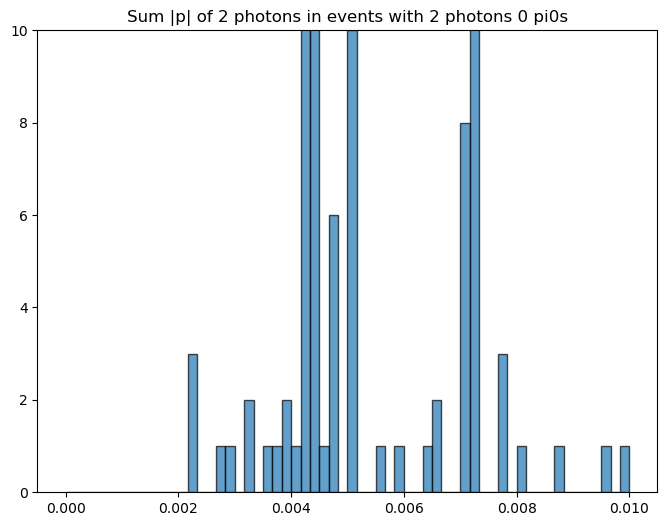

In [15]:
#im asked to make 2 plots:
#for NOPi0, gamma=2:plot p
#for Pi0('s), gamma =2: plot p

#to go from the 0pi0 to pi0>0 case, change the if statement toward the bottom
#also change the label so it's correct

PFSP_array = tree["TMonteCarloEVNTChunk/TMonteCarloEVNTChunk.data_.PFSP[127][4]"].array()
print(len(PFSP_array))

#these are counts of the 5 particle types specified above for each evnt
counts_all_events = modified_turn_IPFS_dump_to_list(r'C:\Users\Mathias\Desktop\NEUTRINO CODING\event # followed by NFSP followed by IPFS.txt')


# first, let's modify how we read the IPFS dump to track particle positions
def get_photon_positions(IPFS_dump_file):
    photon_positions_all_events = []
    
    with open(IPFS_dump_file, 'r') as IPFS_dump:
        for line in IPFS_dump:
            parts_line = line.strip().split()
            particle_line = parts_line[2:]  
            
            photon_positions = []
            for pos, particle_id in enumerate(particle_line):
                if particle_id == '1':
                    photon_positions.append(pos)
            
            photon_positions_all_events.append(photon_positions)
    
    return photon_positions_all_events

# photon positions for all events: eg [[2,6],[1,13,15],...]
photon_positions = get_photon_positions(r'C:\Users\Mathias\Desktop\NEUTRINO CODING\event # followed by NFSP followed by IPFS.txt')


# events with 2 gammas and 0 pi0s
energies = []
for i, entry in enumerate(counts_all_events):
    if entry[0] == 2 and entry[3] == 0:  # 2 gammas, 0 pi0s. remmeber we're in the 5-vector IPFS-counts
        # get 4-momentum data for this event
        event_data = ak.to_numpy(PFSP_array[i][0])
        
        # sum momenta of only the photons
        photon_momentum_sum = 0
        for photon_pos in photon_positions[i]:
            # each particle has 4 values, |p| is the 4th
            #so for particle at position n, |p| is at index n*4 + 3
            momentum_index = photon_pos * 4 + 3
            photon_momentum_sum += event_data[momentum_index]
        
        energies.append(photon_momentum_sum)

plt.figure(figsize=(8, 6))
plt.hist(energies, bins=60, alpha=0.7, edgecolor='black', range=(0, .01))
plt.title('Sum |p| of 2 photons in events with 2 photons 0 pi0s')
plt.ylim(0,10)
plt.show()

### #below: calculating INVARIANT MASS OF EVNTS WITH 2GAMMAS. BASICALLY IT IS CLEAR FROM THE 135 MEV PEAK THAT SOME PI0'S ARE UNRECORDED IN IPFS BUT THEIR DECAY PHOTONS ARE

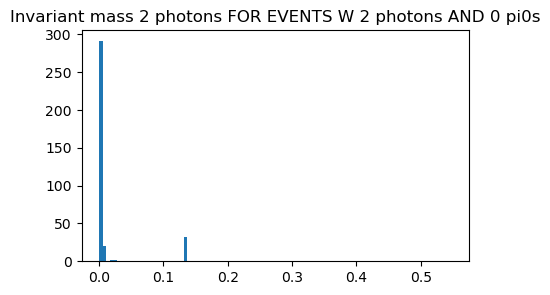

In [16]:


# THIS IS CURRENTLY FOR events with 2 gammas and 0 
#TO CHANGE TO pi0>0, just change the "entry[3] == 0" and also 
invariant_masses = []
for i, entry in enumerate(counts_all_events): #rememeber the "counts_all_events" comes from the MODIFIED IPFS to dump where its [gamma,e+,e-,pi0,eta]
    if entry[0] == 2 and entry[3] == 0:  # 2 gammas, 0 pi0s
        event_data = ak.to_numpy(PFSP_array[i][0])
        
        #photon positions is a function we already created above.
        if len(photon_positions[i]) == 2:
            pos1, pos2 = photon_positions[i] #eg 5,7
            
            #extract momentum components (px/|p|, py/|p|, pz/|p|, |p|)
            idx1 = pos1 * 4      # Eg if position is 0 then idx1 is 0. then u go from 0 thru 3 to enxtract the relevant vars
            idx2 = pos2 * 4      #and whatever the position in the IPFS dump a photon is, u go x4 that because postion 0 index 0, pos 1 gives index 4 etc
            
            # unit vectors and magnitudes
            px1_unit, py1_unit, pz1_unit, p1_mag = event_data[idx1:idx1+4]
            px2_unit, py2_unit, pz2_unit, p2_mag = event_data[idx2:idx2+4]
    
            # cos(theta) from dot product of unit vectors
            cos_theta = px1_unit*px2_unit + py1_unit*py2_unit + pz1_unit*pz2_unit
            
            # INVARAIANT MASS FROM FORMULA HIRO SENT IN CHAT
            m_inv = np.sqrt(2 * p1_mag * p2_mag * (1 - cos_theta))
            invariant_masses.append(m_inv)

# Plot
plt.figure(figsize=(5, 3))
plt.hist(invariant_masses, bins=100)
plt.title('Invariant mass 2 photons FOR EVENTS W 2 photons AND 0 pi0s')
#plt.xlim(.13,.14)
#plt.ylim(0,10)
plt.show()